# AI/ML Bootcamp Lecture 4

## MNIST Handwritten digit classifier continued
For this in-class exercise we will look at the MNIST handwritten digit dataset and classify them using different types of neural networks using keras and tensorflow.

### Imports and style

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import matplotlib.pyplot as plt
height = 5
plt.rcParams["figure.figsize"] = [1.618*height, height]

### Load the MNIST data into a NumPy arrays

In [ ]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
# Plot 6 images from the training set
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

In [ ]:
# Build a MLP model
model = keras.Sequential()
model.add(layers.Flatten(input_shape=(28, 28)))  # Flatten the input images
model.add(layers.Dense(512, activation='relu'))  # Hidden layer with 128
model.add(layers.Dense(512, activation='relu'))  # Hidden layer with 128
model.add(layers.Dense(512, activation='relu'))  # Hidden layer with 128
model.add(layers.Dense(10, activation='softmax'))  # Output layer with 10 classes

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train the model
history = model.fit(train_images, train_labels, epochs=20, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8985 - loss: 0.9863 - val_accuracy: 0.9449 - val_loss: 0.2220
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9476 - loss: 0.1945 - val_accuracy: 0.9544 - val_loss: 0.1749
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9557 - loss: 0.1595 - val_accuracy: 0.9548 - val_loss: 0.1627
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9601 - loss: 0.1492 - val_accuracy: 0.9427 - val_loss: 0.2360
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9654 - loss: 0.1314 - val_accuracy: 0.9628 - val_loss: 0.1415
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9693 - loss: 0.1202 - val_accuracy: 0.9628 - val_loss: 0.1648
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9733 - loss: 0.1040 - val_accuracy: 0.9592 - val_loss: 0.1829
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9770 - loss: 0.0937 - 

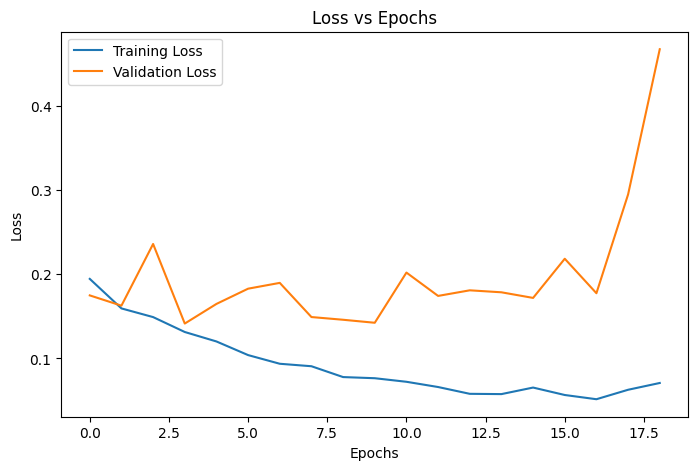

In [ ]:
# Plot loss and val loss
plt.figure()
plt.plot(history.history['loss'][1:], label='Training Loss')
plt.plot(history.history['val_loss'][1:], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()